# Liquid-metal divertor source analysis

This notebook only reads completed OpenEdge results. It does not launch OpenEdge.

Run both backgrounds from a terminal:

```bash
mpirun -np 4 /path/to/spa_mpi -in in.openedge
```


In [14]:
from pathlib import Path
import sys

EXAMPLE_ROOT = Path.cwd().resolve()
if EXAMPLE_ROOT.name == "scripts":
    EXAMPLE_ROOT = EXAMPLE_ROOT.parent
if not (EXAMPLE_ROOT / "in.openedge").exists():
    EXAMPLE_ROOT = Path("examples/workflows/particulates/cat_liquid_metal_divertor").resolve()
sys.path.insert(0, str(EXAMPLE_ROOT / "scripts"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import plotter

plotter.use_paper_style()
plotter.bump_notebook_fonts(px=18)

OUTPUT_ROOT = EXAMPLE_ROOT / "output"
WALL = EXAMPLE_ROOT / "input" / "wall.surf"

CASES = ["attached", "detached"]
LEGS = ["inner", "outer"]
LEG_BOUNDS = {"inner": (165, 223), "outer": (256, 397)}
DT = 5.0e-5


## Available results


In [15]:
availability = []
for case in CASES:
    output_dir = OUTPUT_ROOT / case
    availability.append({
        "case": case,
        "inner_state": (output_dir / "surface_state_inner.csv").exists(),
        "outer_state": (output_dir / "surface_state_outer.csv").exists(),
        "surface_dumps": sum(len(list(output_dir.glob(f"surf_flux_{leg}.*"))) for leg in LEGS),
        "droplet_history": (output_dir / "droplet_evap_total.csv").exists(),
    })
pd.DataFrame(availability)


,case,inner_state,outer_state,surface_dumps,droplet_history
0,attached,True,True,204,True
1,detached,True,True,204,True


## Geometry and labels


In [16]:
def parse_surface(path):
    points = {}
    segments = []
    section = None
    for raw in Path(path).read_text().splitlines():
        text = raw.strip()
        if not text or text.startswith("#"):
            continue
        if text.lower() in {"points", "lines"}:
            section = text.lower()
            continue
        if not text[0].isdigit():
            continue
        fields = text.split()
        if section == "points":
            points[int(fields[0])] = (float(fields[1]), float(fields[2]))
        elif section == "lines":
            segments.append(tuple(map(int, fields[:3])))
    return points, segments


def leg_geometry(path, bounds):
    points, segments = parse_surface(path)
    lo, hi = bounds
    mid_by_id = {}
    area_by_id = {}
    for surface_id, point_1, point_2 in sorted(segments):
        if not lo <= surface_id <= hi:
            continue
        x1, y1 = points[point_1]
        x2, y2 = points[point_2]
        length = float(np.hypot(x2 - x1, y2 - y1))
        # axi slot convention: slot-x = Z, slot-y = R
        mid_by_id[surface_id] = (0.5 * (y1 + y2), 0.5 * (x1 + x2))  # (R, Z)
        area_by_id[surface_id] = 2.0 * np.pi * 0.5 * (y1 + y2) * length
    return mid_by_id, area_by_id


def load_target_curve(case, leg):
    """SOLPS ld_tg polyline for this case/leg: (L-Lsep, R, Z)."""
    tag = "i" if leg == "inner" else "o"
    d = np.genfromtxt(EXAMPLE_ROOT / "input" / f"ld_tg_{tag}_{case}.dat",
                      comments="#")
    d = d[~np.isnan(d).all(axis=1)]
    return d[:, 0], d[:, 14], d[:, 15]


def llsep_of_faces(case, leg, surface_ids):
    """L-Lsep of each face: continuous projection of the face midpoint
    onto the SOLPS target polyline. Jeremy's paper coordinate; avoids
    both the id-order mirroring and the nearest-point staircase."""
    x, R, Z = load_target_curve(case, leg)
    mid_by_id, _ = LEG_GEOMETRY[leg]
    out = np.empty(len(surface_ids))
    for n, sid in enumerate(surface_ids):
        r0, z0 = mid_by_id[int(sid)]
        best_d2, best_x = 1e30, x[0]
        for k in range(len(x) - 1):
            dr, dz = R[k + 1] - R[k], Z[k + 1] - Z[k]
            L2 = dr * dr + dz * dz
            t = 0.0 if L2 == 0 else min(max(
                ((r0 - R[k]) * dr + (z0 - Z[k]) * dz) / L2, 0.0), 1.0)
            d2 = (r0 - (R[k] + t * dr)) ** 2 + (z0 - (Z[k] + t * dz)) ** 2
            if d2 < best_d2:
                best_d2, best_x = d2, x[k] + t * (x[k + 1] - x[k])
        out[n] = best_x
    return out


LEG_GEOMETRY = {leg: leg_geometry(WALL, bounds) for leg, bounds in LEG_BOUNDS.items()}


## Surface state

The CSV is written by \`fix surface/state/lm\` in the same OpenEdge run that evaluates the source terms.


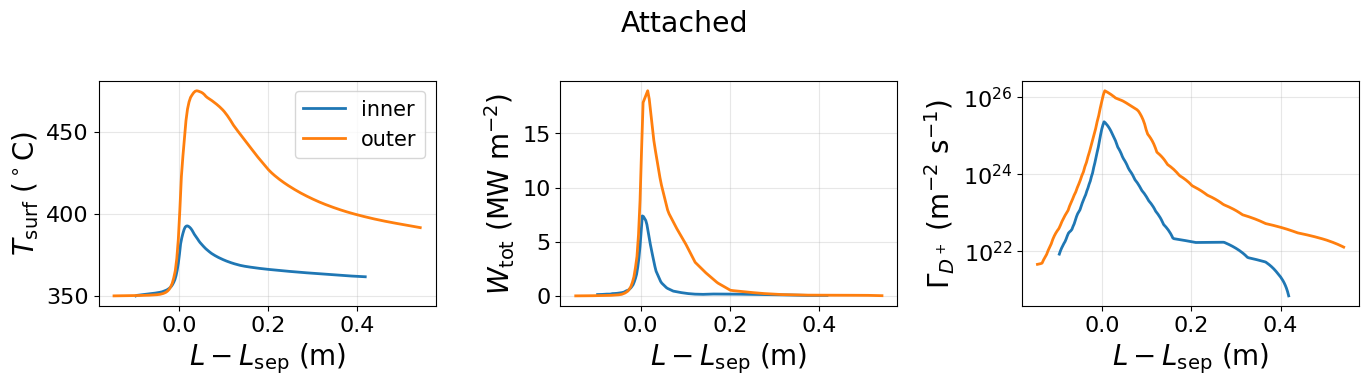

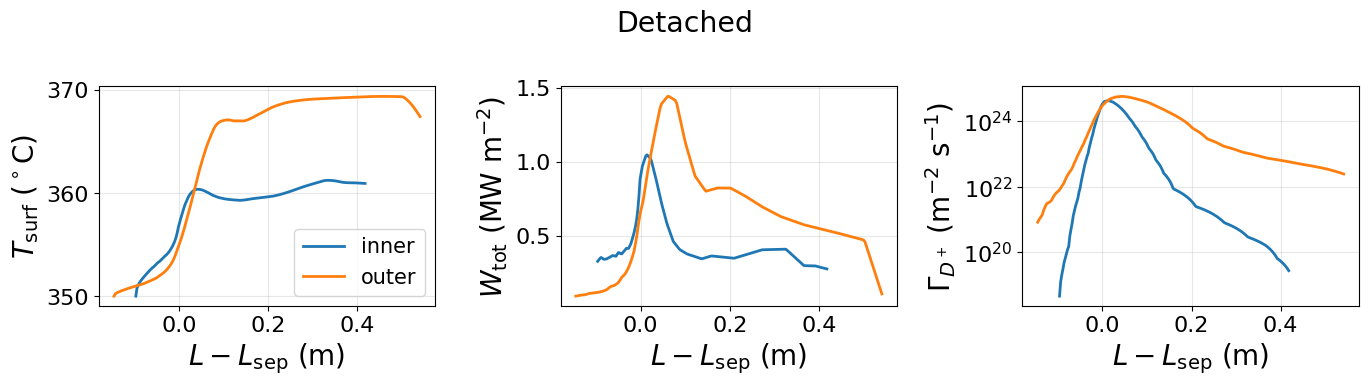

In [17]:
surface_frames = {}
for case in CASES:
    for leg in LEGS:
        csv_path = OUTPUT_ROOT / case / f"surface_state_{leg}.csv"
        if csv_path.exists():
            surface_frames[(case, leg)] = pd.read_csv(csv_path)

for case in CASES:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True)
    for leg in LEGS:
        frame = surface_frames.get((case, leg))
        if frame is None:
            continue
        if "L_Lsep_m" in frame:
            xax = frame["L_Lsep_m"]
        else:  # older CSVs: rebase with the file's own L-Lsep origin
            xax = frame["s_m"] + load_target_curve(case, leg)[0].min()
        axes[0].plot(xax * 100, frame["Tsurf_C"], lw=2, label=leg)
        axes[1].plot(xax * 100, frame["Wtot_Wm2"] * 1e-6, lw=2, label=leg)
        axes[2].semilogy(xax * 100, frame["Gamma_D_m2s"], lw=2, label=leg)

    for axis, ylabel in zip(
        axes,
        [r"$T_\mathrm{surf}$ ($^\circ$C)", r"$W_\mathrm{tot}$ (MW m$^{-2}$)", r"$\Gamma_{D^+}$ (m$^{-2}$ s$^{-1}$)"],
    ):
        axis.set_xlabel(r"$L-L_\mathrm{sep}$ (cm)")
        axis.set_xlim(-10, 50)
        axis.set_ylabel(ylabel)
        axis.grid(True, which="both", alpha=0.3)
    axes[0].legend()
    fig.suptitle(case.capitalize())
    plt.tight_layout()
    plt.show()


## Wall-source profiles


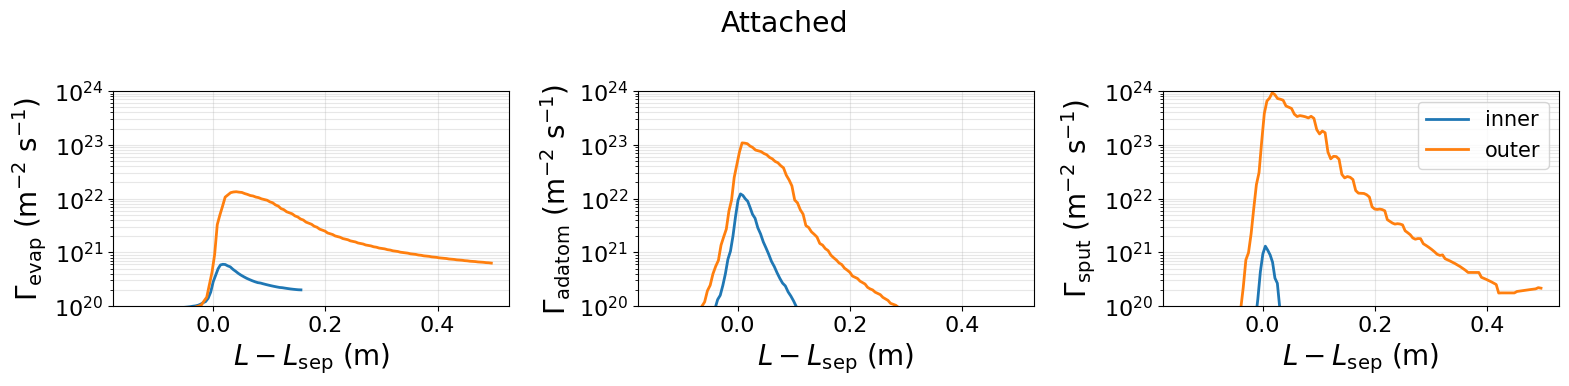

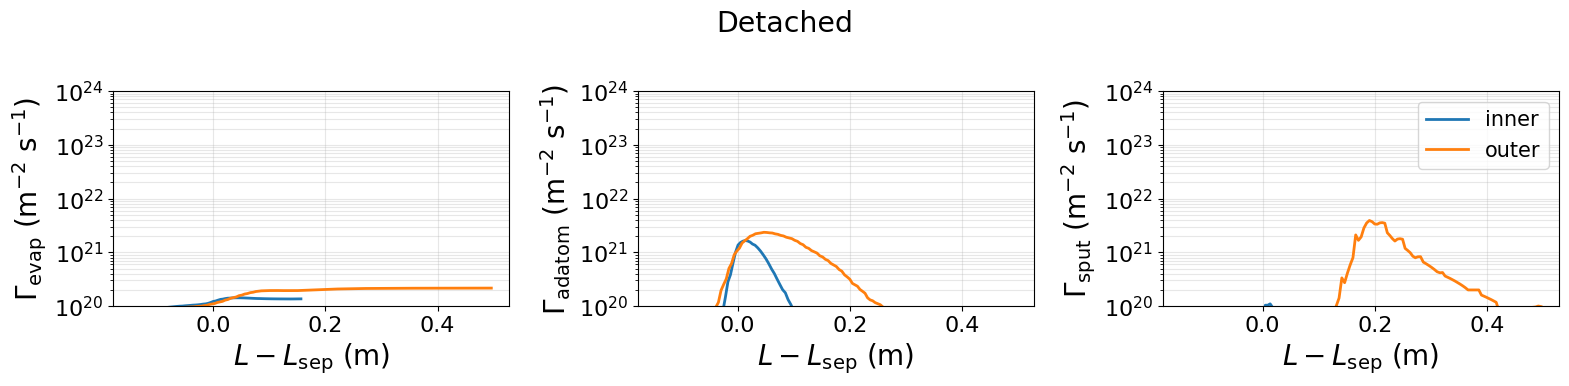

In [18]:
wall_profiles = {}

for case in CASES:
    for leg in LEGS:
        prefix = f"c_cpmiLi_{leg}"
        surface_ids, data = plotter.read_surf_flux(
            str(OUTPUT_ROOT / case / f"surf_flux_{leg}.0"),
            columns=(f"c_cevap_{leg}", f"c_cadat_{leg}", f"{prefix}[1]"),
        )
        if len(surface_ids) == 0:
            continue
        mid_by_id, area_by_id = LEG_GEOMETRY[leg]
        s = llsep_of_faces(case, leg, surface_ids)
        area = np.asarray([area_by_id[int(surface_id)] for surface_id in surface_ids])
        order = np.argsort(s)
        wall_profiles[(case, leg)] = {
            "s": s[order],
            "area": area[order],
            "Gamma_evap": np.asarray(data[f"c_cevap_{leg}"])[order],
            "Gamma_adatom": np.asarray(data[f"c_cadat_{leg}"])[order],
            "Gamma_sput": np.asarray(data[f"{prefix}[1]"])[order],
        }

fields = [
    ("Gamma_evap", r"$\Gamma_\mathrm{evap}$"),
    ("Gamma_adatom", r"$\Gamma_\mathrm{adatom}$"),
    ("Gamma_sput", r"$\Gamma_\mathrm{sput}$"),
]
for case in CASES:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True)
    for leg in LEGS:
        profile = wall_profiles.get((case, leg))
        if profile is None:
            continue
        for axis, (field, ylabel) in zip(axes, fields):
            values = np.where(profile[field] > 0, profile[field], np.nan)
            axis.semilogy(profile["s"] * 100, values, lw=2, label=leg)
            axis.set_ylim(1e20, 1e24)
            axis.set_xlim(-10, 50)
            axis.set_xlabel(r"$L-L_\mathrm{sep}$ (cm)")
            axis.set_ylabel(ylabel + r" (m$^{-2}$ s$^{-1}$)")
            axis.grid(True, which="both", alpha=0.3)
    axes[-1].legend()
    fig.suptitle(case.capitalize())
    plt.tight_layout()
    plt.show()


## Integrated source summary


In [19]:
summary_rows = []
for (case, leg), profile in wall_profiles.items():
    area = profile["area"]
    target_area = float(np.nansum(area))
    row = {"case": case, "leg": leg, "target_area_m2": target_area}
    for field, name in [("Gamma_evap", "evap"), ("Gamma_adatom", "adatom"), ("Gamma_sput", "sputter")]:
        total = float(np.nansum(profile[field] * area))
        row[f"Q_{name}_s-1"] = total
        row[f"Gamma_{name}_avg"] = total / target_area
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).sort_values(["case", "leg"]).reset_index(drop=True)
summary_df


,case,leg,target_area_m2,Q_evap_s-1,Gamma_evap_avg,Q_adatom_s-1,Gamma_adatom_avg,Q_sputter_s-1,Gamma_sputter_avg
0,attached,inner,4.412712,1.016173e+21,2.302831e+20,6.338128e+21,1.436334e+21,4.397217e+20,9.964885e+19
1,attached,outer,14.526811,3.975628e+22,2.736752e+21,1.510285e+23,1.039654e+22,1.189201e+24,8.186250e+22
2,detached,inner,4.412712,5.338409e+20,1.209780e+20,1.569310e+21,3.556339e+20,6.309746e+19,1.429902e+19
3,detached,outer,14.526811,2.497055e+21,1.718928e+20,7.068317e+21,4.865705e+20,7.061380e+21,4.860929e+20


## Sputtering by projectile element

The total is checked against the sum of all D, Ne, and Li charge-state channels. These runs use the IEAD-weighted analytic Eckstein/Yamamura fallback with $U_s=1$ eV because angle-energy D/Ne/Li-on-Li tables are not installed. Treat the sputtering magnitude and shape as provisional, especially at grazing incidence.


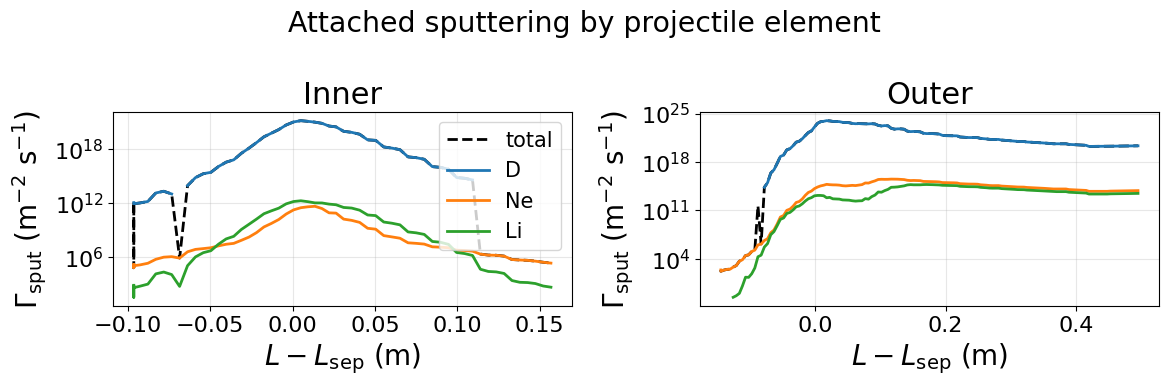

attached: max |sum(components) - total| / total = 8.06e-06


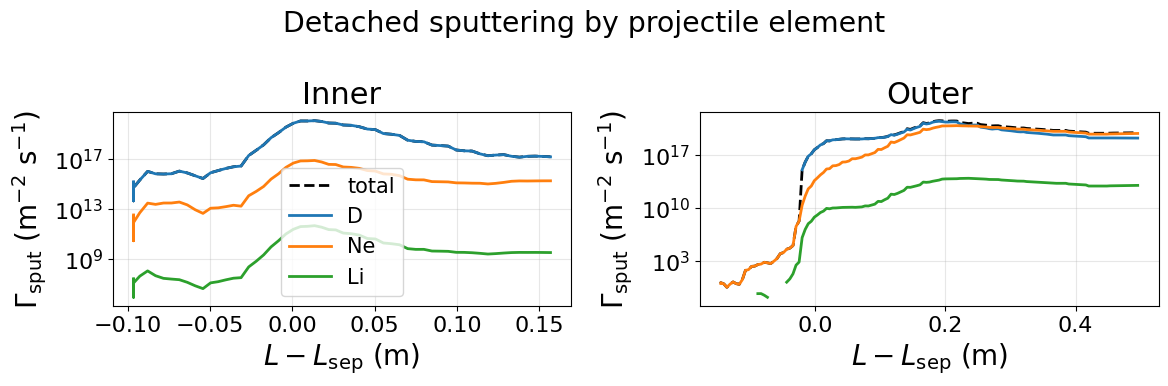

detached: max |sum(components) - total| / total = 8.42e-06


In [20]:
element_groups = {
    "D": (2,),
    "Ne": tuple(range(3, 13)),
    "Li": tuple(range(13, 16)),
}

for case in CASES:
    fig, axes = plt.subplots(1, len(LEGS), figsize=(12, 4), squeeze=False)
    max_relative_error = 0.0
    for column, leg in enumerate(LEGS):
        axis = axes[0, column]
        prefix = f"c_cpmiLi_{leg}"
        columns = tuple(f"{prefix}[{index}]" for index in range(1, 16))
        surface_ids, data = plotter.read_surf_flux(
            str(OUTPUT_ROOT / case / f"surf_flux_{leg}.0"),
            columns=columns,
        )
        if len(surface_ids) == 0:
            continue
        s_by_id, _ = LEG_GEOMETRY[leg]
        s = llsep_of_faces(case, leg, surface_ids)
        order = np.argsort(s)
        s = s[order]
        total = np.asarray(data[f"{prefix}[1]"])[order]
        component_sum = np.zeros_like(total)
        axis.semilogy((s) * 100, np.where(total > 0, total, np.nan), "k--", lw=2, label="total")
        for label, indices in element_groups.items():
            values = sum(
                (np.asarray(data[f"{prefix}[{index}]"])[order] for index in indices if f"{prefix}[{index}]" in data),
                start=np.zeros_like(total),
            )
            component_sum += values
            axis.semilogy((s) * 100, np.where(values > 0, values, np.nan), lw=2, label=label)
        scale = np.maximum(np.abs(total), np.finfo(float).tiny)
        max_relative_error = max(max_relative_error, float(np.max(np.abs(component_sum - total) / scale)))
        axis.set_title(leg.capitalize())
        axis.set_xlabel(r"$L-L_\mathrm{sep}$ (cm)")
        axis.set_xlim(-10, 50)
        axis.set_ylabel(r"$\Gamma_\mathrm{sput}$ (m$^{-2}$ s$^{-1}$)")
        axis.grid(True, which="both", alpha=0.3)
    axes[0, 0].legend()
    fig.suptitle(f"{case.capitalize()} sputtering by projectile element")
    plt.tight_layout()
    plt.show()
    print(f"{case}: max |sum(components) - total| / total = {max_relative_error:.2e}")


## Droplet trajectories


attached: 45 droplets, columns: ['id', 'type', 'x', 'y', 'z', 'vx', 'vy', 'vz', 'radius', 'temp', 'p_droplet_heating_q', 'p_droplet_a_over_lambdaD', 'p_droplet_oml_weight']


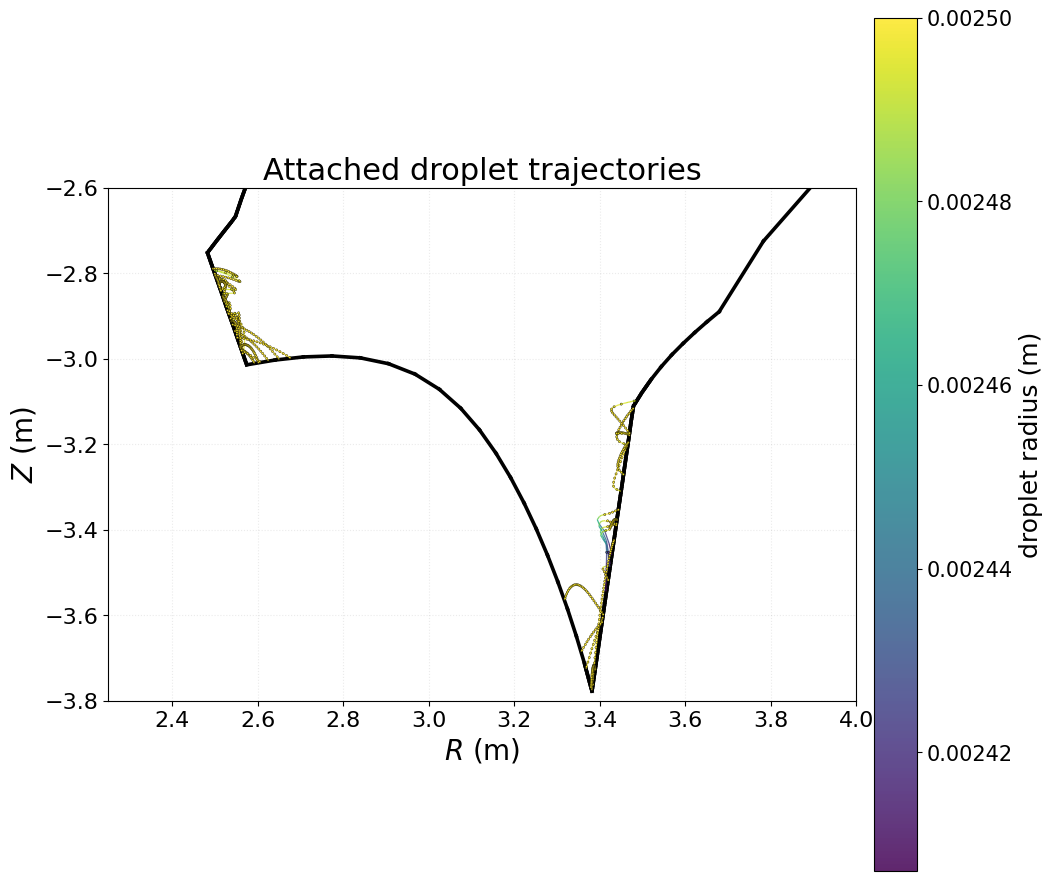

detached: 45 droplets, columns: ['id', 'type', 'x', 'y', 'z', 'vx', 'vy', 'vz', 'radius', 'temp', 'p_droplet_heating_q', 'p_droplet_a_over_lambdaD', 'p_droplet_oml_weight']


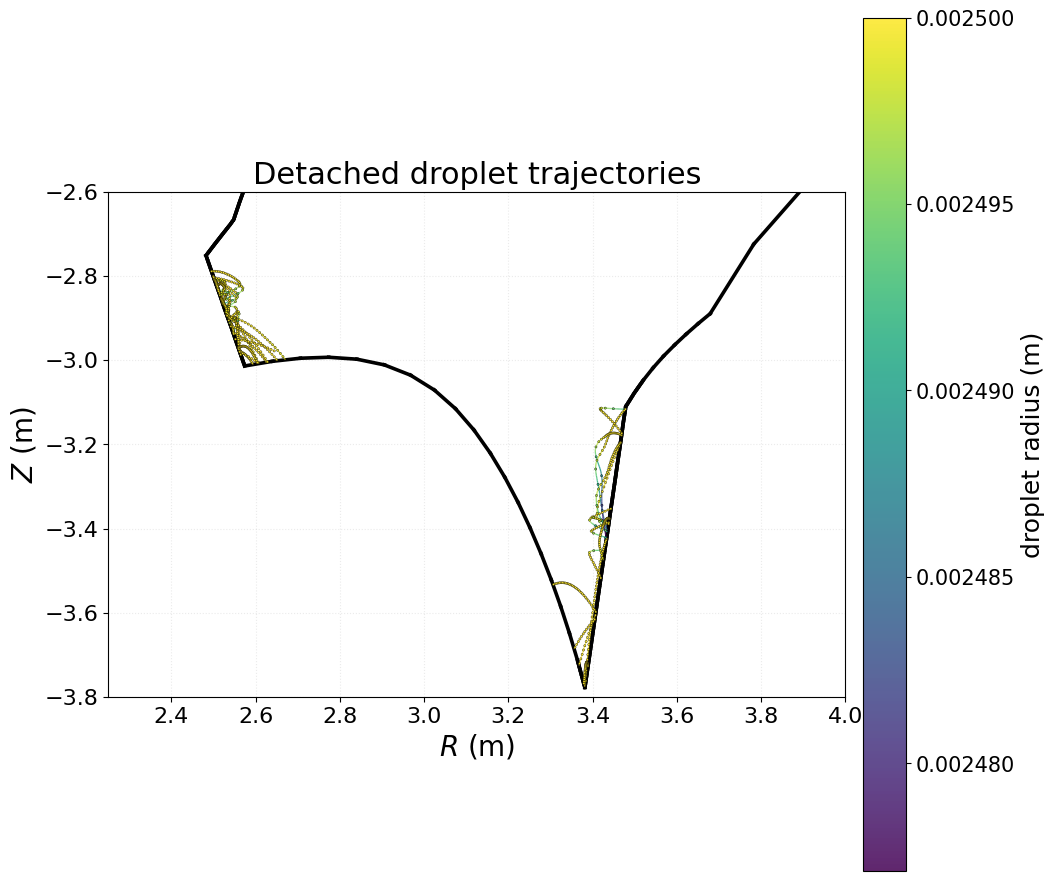

In [21]:
wall_points, wall_lines = parse_surface(WALL)
last_wall_line = max(surface_id for surface_id, *_ in wall_lines)

for case in CASES:
    dump_path = OUTPUT_ROOT / case / "dump.txt"
    if not dump_path.exists():
        print(f"{case}: no {dump_path.relative_to(EXAMPLE_ROOT)}")
        continue

    columns, trajectories = plotter.read_trajectories(dump_path)
    print(f"{case}: {len(trajectories)} droplets, columns: {columns}")
    fig, ax = plotter.plot_trajectories_on_wall(
        wall_points,
        wall_lines,
        last_wall_line,
        trajectories,
        color_by="radius",
        dot_every=10,
        dot_scale=1e3,
        title=f"{case.capitalize()} droplet trajectories",
        axisymmetric=True,
    )
    ax.set_xlim(2.25, 4)
    ax.set_ylim(-3.8,-2.6)



    plt.show()
